In [1]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Dense

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], dtype= int )

In [8]:
X = df.drop("Exited", axis = 1)
y = df["Exited"]

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [12]:
model = Sequential()
model.add(Dense(units = 3, activation = 'sigmoid', input_dim = 13))
model.add(Dense(units = 2, activation = 'sigmoid'))
model.add(Dense(units = 1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53 (212.00 B)

 Trainable params: 53 (212.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(optimizer='adam', loss = 'binary_crossentropy', metrics=['accuracy'])

In [15]:
print(model.layers[0].get_weights())
print(model.layers[1].get_weights())

[array([[-0.6011768 , -0.5251509 , -0.3869334 ],
       [-0.30853248, -0.14376381, -0.21525317],
       [-0.49510434,  0.3639956 , -0.03113997],
       [ 0.5829404 , -0.2323125 , -0.38789275],
       [-0.00967038,  0.54226965, -0.60171455],
       [ 0.44536155,  0.16385967,  0.00605804],
       [ 0.45612627, -0.02628833,  0.23193449],
       [-0.15997997, -0.37113914, -0.12841925],
       [ 0.45559067, -0.47382993,  0.49650246],
       [ 0.48261267, -0.34382105,  0.01925313],
       [ 0.5184551 ,  0.22191274, -0.17748433],
       [-0.22885856,  0.06855989,  0.32522243],
       [-0.36242464, -0.3559784 , -0.42645088]], dtype=float32), array([0., 0., 0.], dtype=float32)]
[array([[-0.2968734 , -1.0469357 ],
       [-0.6496655 ,  0.69266653],
       [-0.71792996,  0.2308129 ]], dtype=float32), array([0., 0.], dtype=float32)]


In [16]:
model.fit(X_train, y_train, batch_size = 50, epochs = 10, verbose = 1, validation_split = 0.2)

Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7957 - loss: 0.6284 - val_accuracy: 0.7969 - val_loss: 0.5791
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7904 - loss: 0.5701 - val_accuracy: 0.7969 - val_loss: 0.5365
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7969 - loss: 0.5303 - val_accuracy: 0.7969 - val_loss: 0.5122
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8021 - loss: 0.5041 - val_accuracy: 0.7969 - val_loss: 0.4988
Epoch 5/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8018 - loss: 0.4907 - val_accuracy: 0.7969 - val_loss: 0.4907
Epoch 6/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7983 - loss: 0.4872 - val_accuracy: 0.7969 - val_loss: 0.4853
Epoch 7/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7984 - loss: 0.4821 - val_accuracy: 0.7969 - val_loss: 0.4808
Epoch 8/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8008 - loss: 0.4742 - val_accuracy: 0.

In [18]:
y_pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [20]:
y_pred = y_pred.argmax(axis = -1)

In [21]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7975

---
# REGRESSION





In [23]:
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [24]:
# minmax scalar
# only scale x, Reason: y we have to predict
scalar = MinMaxScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

model = Sequential()
model.add(Dense(7, activation='relu', input_dim=X_train.shape[1])) # Use input_dim based on X_train shape
model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=100, batch_size=10, verbose=1)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7862 - loss: 0.1954
Epoch 2/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8047 - loss: 0.1519
Epoch 3/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8064 - loss: 0.1445
Epoch 4/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8155 - loss: 0.1388
Epoch 5/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8244 - loss: 0.1291
Epoch 6/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8266 - loss: 0.1310
Epoch 7/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8221 - loss: 0.1318
Epoch 8/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8311 - loss: 0.1285
Epoch 9/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8315 - loss: 0.1304
Epoch 10/100
162/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8379 - loss: 0.1278

KeyboardInterrupt: 

In [25]:
y_pred = model.predict(x_test)
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
print(r2_score(y_test, y_pred))

NameError: name 'x_test' is not defined

---
# Regularization Technique : Early Stopping

In [29]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles


<Axes: >

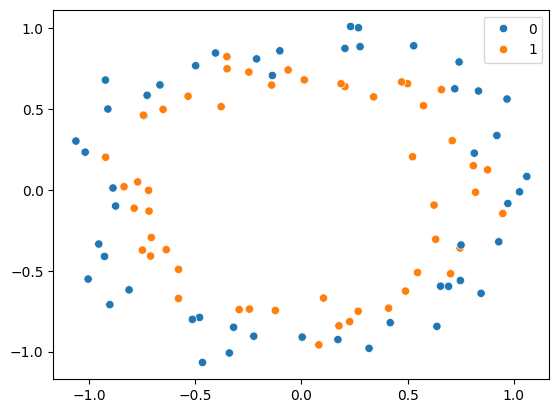

In [30]:
X, y = make_circles(n_samples=100, noise=0.1, random_state=1)
sns.scatterplot(x= X[:,0],y = X[:,1],hue=y)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [32]:
model = Sequential()
model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


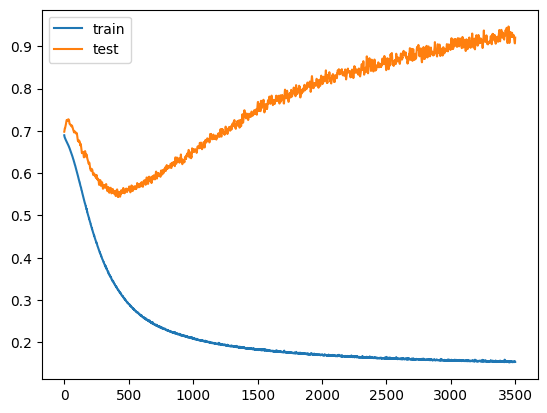

In [33]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 956us/step


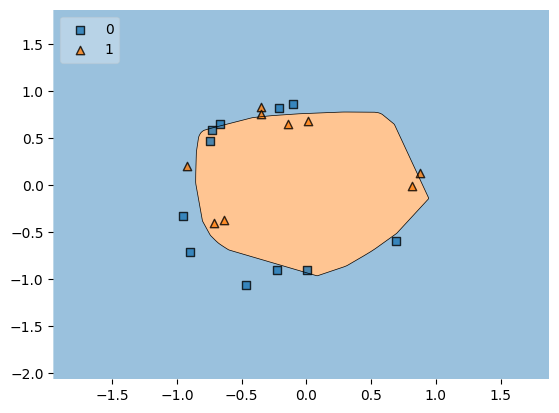

In [34]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

Epoch 1/3500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.3812 - loss: 0.6995 - val_accuracy: 0.4000 - val_loss: 0.6945
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5227 - loss: 0.6931 - val_accuracy: 0.4000 - val_loss: 0.6956
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5461 - loss: 0.6919 - val_accuracy: 0.4000 - val_loss: 0.6965
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5164 - loss: 0.6915 - val_accuracy: 0.3500 - val_loss: 0.6975
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5414 - loss: 0.6897 - val_accuracy: 0.3500 - val_loss: 0.6992
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5242 - loss: 0.6889 - val_accuracy: 0.4000 - val_loss: 0.7016
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5344 - loss: 0.6879 - val_accuracy: 0.4500 - val_loss: 0.7034
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6031 - loss: 0.6853 - val_accuracy: 0.4500 - val_loss: 0.7

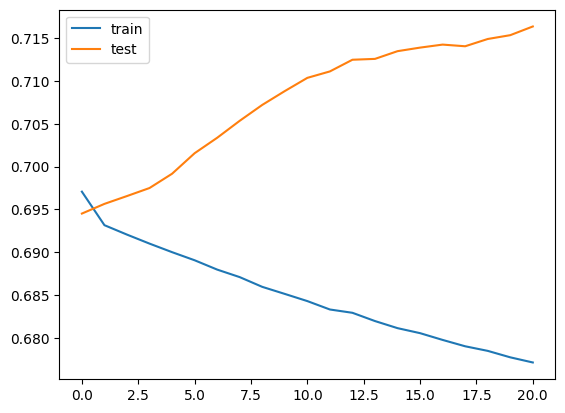

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


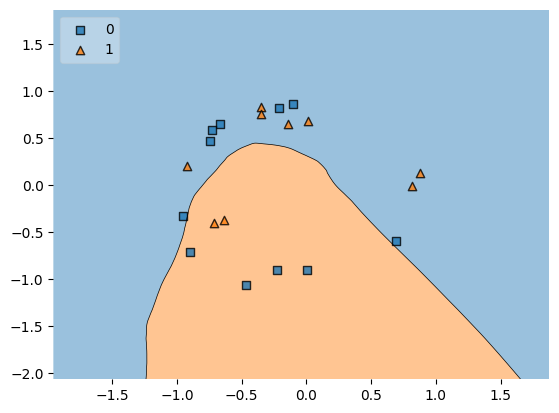

In [35]:
#Early Stopping
model = Sequential()
model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()